In [34]:
import os
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import matplotlib.pyplot as plt;
import shutil
import psutil

import numpy as np
import re

import sys
import pyemu
import flopy

sys.path.insert(0,"..")
import herebedragons as hbd

import subprocess

In [35]:
pst = pyemu.Pst('../ies/peterson_tran.pst')

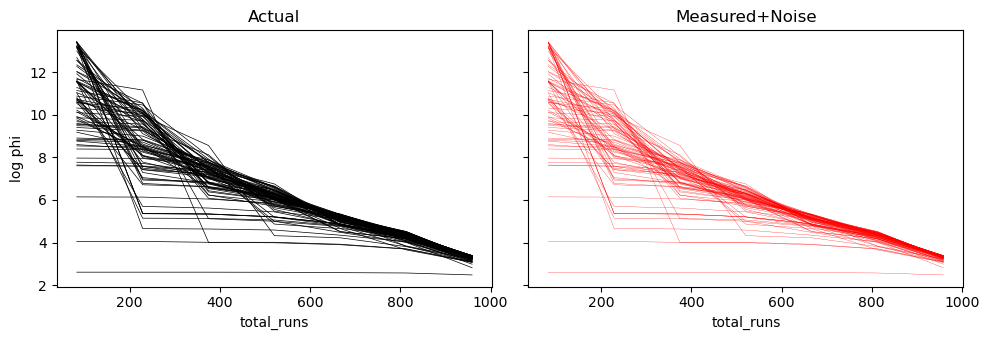

In [36]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10,3.5))
# left
m_d= '../ies'
ax = axes[0]
phi = pd.read_csv(os.path.join(m_d,"peterson_tran.phi.actual.csv"),index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.5,color='k', ax=ax)
ax.set_title(r'Actual')
ax.set_ylabel(r'log phi')
# right
ax = axes[-1]
phi = pd.read_csv(os.path.join(m_d,"peterson_tran.phi.meas.csv"),index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.2,color='r', ax=ax)
ax.set_title(r'Measured+Noise')
fig.tight_layout()

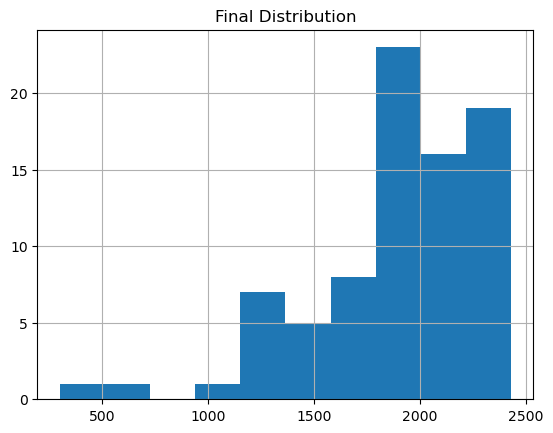

In [37]:
plt.figure()
phi.iloc[-1,6:].hist()
plt.title(r'Final Distribution');

In [38]:
pr_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,"peterson_tran.0.obs.csv"))
pt_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,"peterson_tran.{0}.obs.csv".format(pst.control_data.noptmax)))
noise = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,"peterson_tran.obs+noise.csv"))

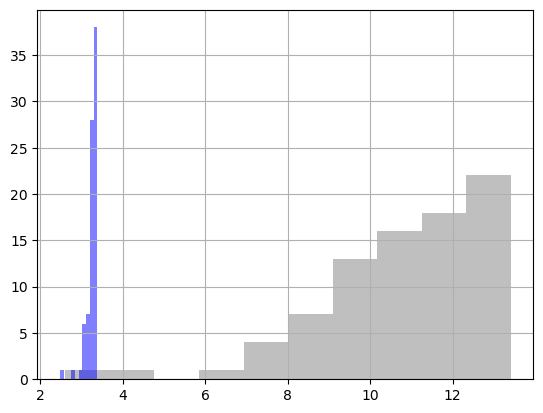

In [39]:
fig,ax = plt.subplots(1,1)
pr_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="0.5",ec="none",alpha=0.5,density=False)
pt_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="b",ec="none",alpha=0.5,density=False)
_ = ax.set_xlabel("")

In [40]:
import glob

# Get all .rei.csv files (assuming they are named consistently like model_1.rei.csv, model_2.rei.csv, etc.)
rei_files = sorted(glob.glob("../ies/peterson_tran.*.base.rei"))  # Adjust the naming pattern as needed

# Read all files into a single DataFrame with an 'iteration' column
rei_list = []
for i, file in enumerate(rei_files, start=1):
    df = pd.read_csv(file)
    df['iteration'] = i  # Assign iteration number
    rei_list.append(df)

rei_df = pd.concat(rei_list, ignore_index=True)


In [41]:
import pandas as pd
import glob

# Find all REI files
rei_files = sorted(glob.glob("../ies/peterson_tran.*.base.rei"))

# Read each file manually, skipping header lines
rei_list = []
for i, file in enumerate(rei_files):
    with open(file, "r") as f:
        lines = f.readlines()

    # Find the start of the data (skipping the header)
    for idx, line in enumerate(lines):
        if line.strip().startswith("Name"):
            start_idx = idx #+ 1
            break

    # Read the table portion
    data = pd.read_csv(file, delim_whitespace=True, skiprows=start_idx)
    data["iteration"] = i + 1  # Add iteration number
    rei_list.append(data)

# Concatenate all iterations into one DataFrame
rei_df = pd.concat(rei_list, ignore_index=True)

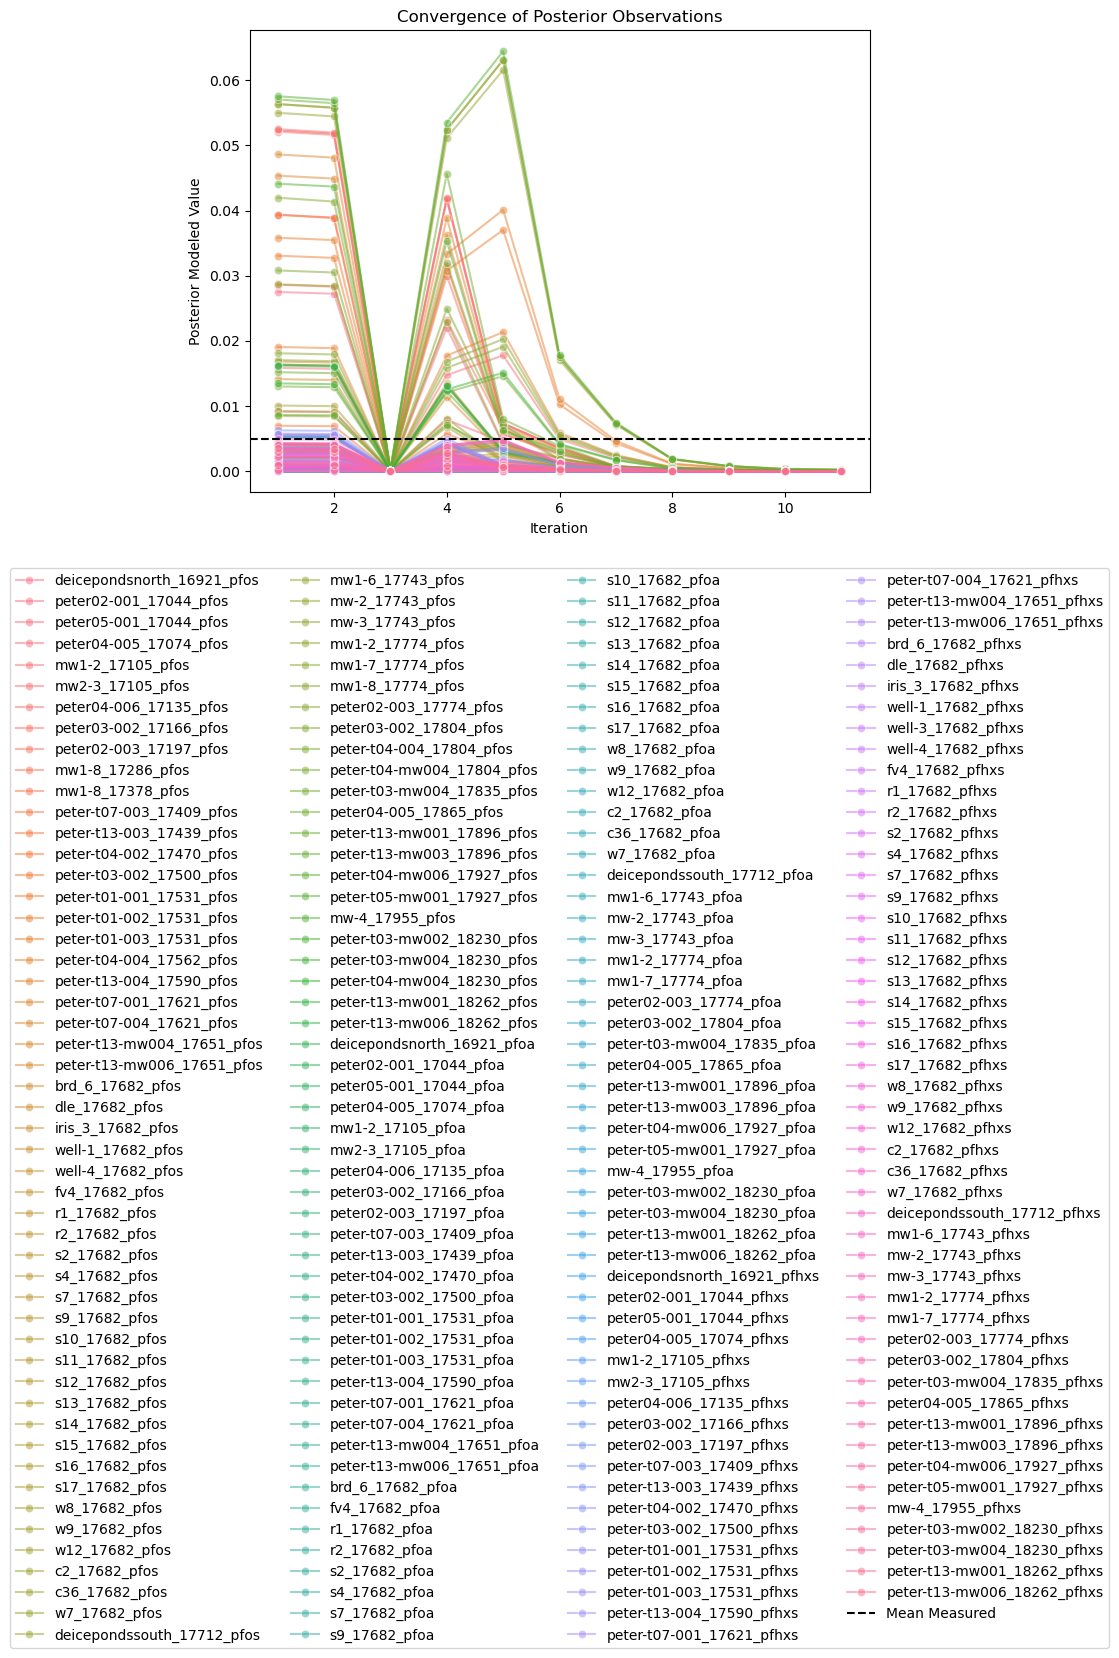

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.lineplot(data=rei_df, x="iteration", y="Modelled", hue="Name", alpha=0.5, marker="o")
plt.axhline(y=rei_df['Measured'].mean(), color="black", linestyle="--", label="Mean Measured")
plt.xlabel("Iteration")
plt.ylabel("Posterior Modeled Value")
plt.title("Convergence of Posterior Observations")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
plt.show()

In [46]:
import seaborn as sns
# Filter for the last iteration
sim_obs= pd.read_csv('../ies/peterson_tran.10.obs.csv', index_col=0)
last_iter = rei_df["iteration"].max()
rei_last = rei_df[rei_df["iteration"] == last_iter].copy()
#rei_last = rei_df[rei_df["iteration"] == last_iter]
rei_last['Simulated']= sim_obs.iloc[-1].values
#sim_obs.iloc[3].values

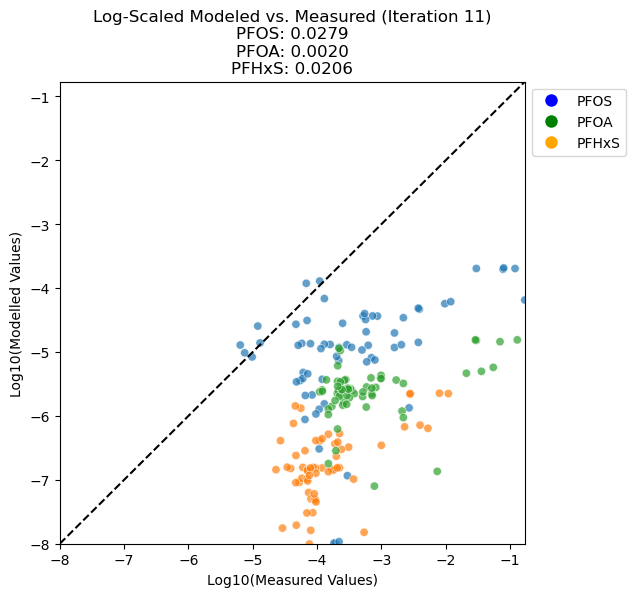

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add a small constant to avoid log(0) for both measured and modeled values
small_constant = 1e-10

# Apply log transformation (log10)
rei_last["log_measured"] = np.log10(rei_last["Measured"] + small_constant)
rei_last["log_modelled"] = np.log10(rei_last["Simulated"] + small_constant)

# Create a mapping for the observation names to colors (for _pfos, _pfoa, _pfhxs)
color_map = {
    "_pfos": "blue",  # Color for PFOS
    "_pfoa": "green",  # Color for PFOA
    "_pfhxs": "red",  # Color for PFHxS
}

# Add a new column to assign colors based on the observation name
def get_category(name):
    if "_pfos" in name:
        return "PFOS"
    elif "_pfoa" in name:
        return "PFOA"
    elif "_pfhxs" in name:
        return "PFHxS"
    else:
        return "Other"  # Default category if name doesn't match

rei_last["category"] = rei_last["Name"].apply(get_category)
rei_last["color"] = rei_last["category"].map({"PFOS": "blue", "PFOA": "green", "PFHxS": "red", "Other": "grey"})

# Calculate RMSE (Root Mean Squared Error) for each category
rmse_values = {}
for category in ["PFOS", "PFOA", "PFHxS"]:
    subset = rei_last[rei_last["category"] == category]
    if not subset.empty:
        rmse_values[category] = np.sqrt(((subset["Simulated"] - subset["Measured"]) ** 2).mean())
    else:
        rmse_values[category] = None  # Handle cases where a category might be missing

# Create the log-log plot with manually set colors
plt.figure(figsize=(6,6))
sns.scatterplot(data=rei_last, x="log_measured", y="log_modelled", hue="color", alpha=0.7, legend=None)

# Add a 1:1 line for reference
plt.plot([-8, 5],
         [-8, 5],
         color="black", linestyle="--", label="1:1 Line")

# Set equal axis limits (same limits for both axes)
min_val = min(rei_last["log_measured"].min(), rei_last["log_modelled"].min())
max_val = max(rei_last["log_measured"].max(), rei_last["log_modelled"].max())

plt.xlim(-8, max_val)
plt.ylim(-8, max_val)

# Labels and title
plt.xlabel("Log10(Measured Values)")
plt.ylabel("Log10(Modelled Values)")

# Format RMSE text for display
rmse_text = "\n".join([f"{key}: {value:.4f}" for key, value in rmse_values.items() if value is not None])

plt.title(f"Log-Scaled Modeled vs. Measured (Iteration {last_iter})\n{rmse_text}")

# Customize the legend manually with specific colors
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='PFOS'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='PFOA'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='PFHxS')
]
plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1,1))  # Move legend outside

# Show the plot
plt.show()


In [51]:
upstream = pd.read_excel('../ies/data-files/tran-PFAS-targets.xlsx')
downstream = pd.read_csv('../ies/data-files/tran-targets-downstream.csv')

In [52]:
pfos_wells= pd.read_csv('../ies/output-files/pfos_obs.csv')

In [53]:
import matplotlib.dates as mdates
from datetime import datetime, timedelta

In [54]:
observations_pfos = pd.read_csv('../ies/data-files/tran-PFOS-observations.csv')

In [55]:
#observations_pfos['time'] = pd.to_datetime(observations_pfos['time'])

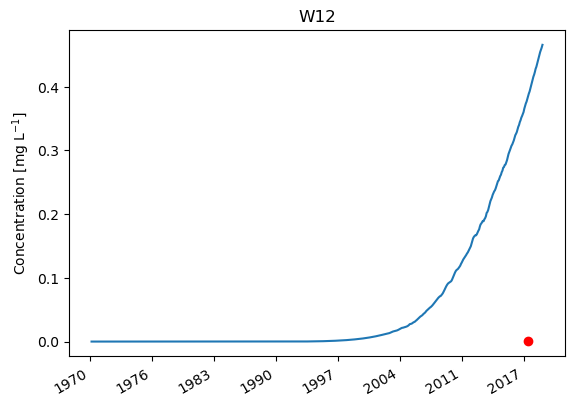

In [66]:


fig, ax = plt.subplots()
convertible_indexes = pfos_wells[pfos_wells['W12'].notna()].index.to_numpy()
well = pfos_wells.loc[convertible_indexes, 'W12'].to_numpy('float64')
# Convert x-axis values (convertible_indexes) to datetime
start_date = datetime(1970, 1, 1)
date_indexes = [start_date + timedelta(days=int(x)) for x in convertible_indexes]

ax.scatter(observations_pfos.time, observations_pfos['W12'] *1e-6 , c='r')
ax.plot(pfos_wells.time, pfos_wells['W12'])#, label=column)
ax.set_ylabel('Concentration [mg L$^{-1}$]')
#ax.set_xlabel('Days since 1970-01-01')
ax.set_title('W12')


# Format x-axis as dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format the x-axis with dates
fig.autofmt_xdate()  # Rotate date labels for better readability

# ax.legend()
    
plt.show()

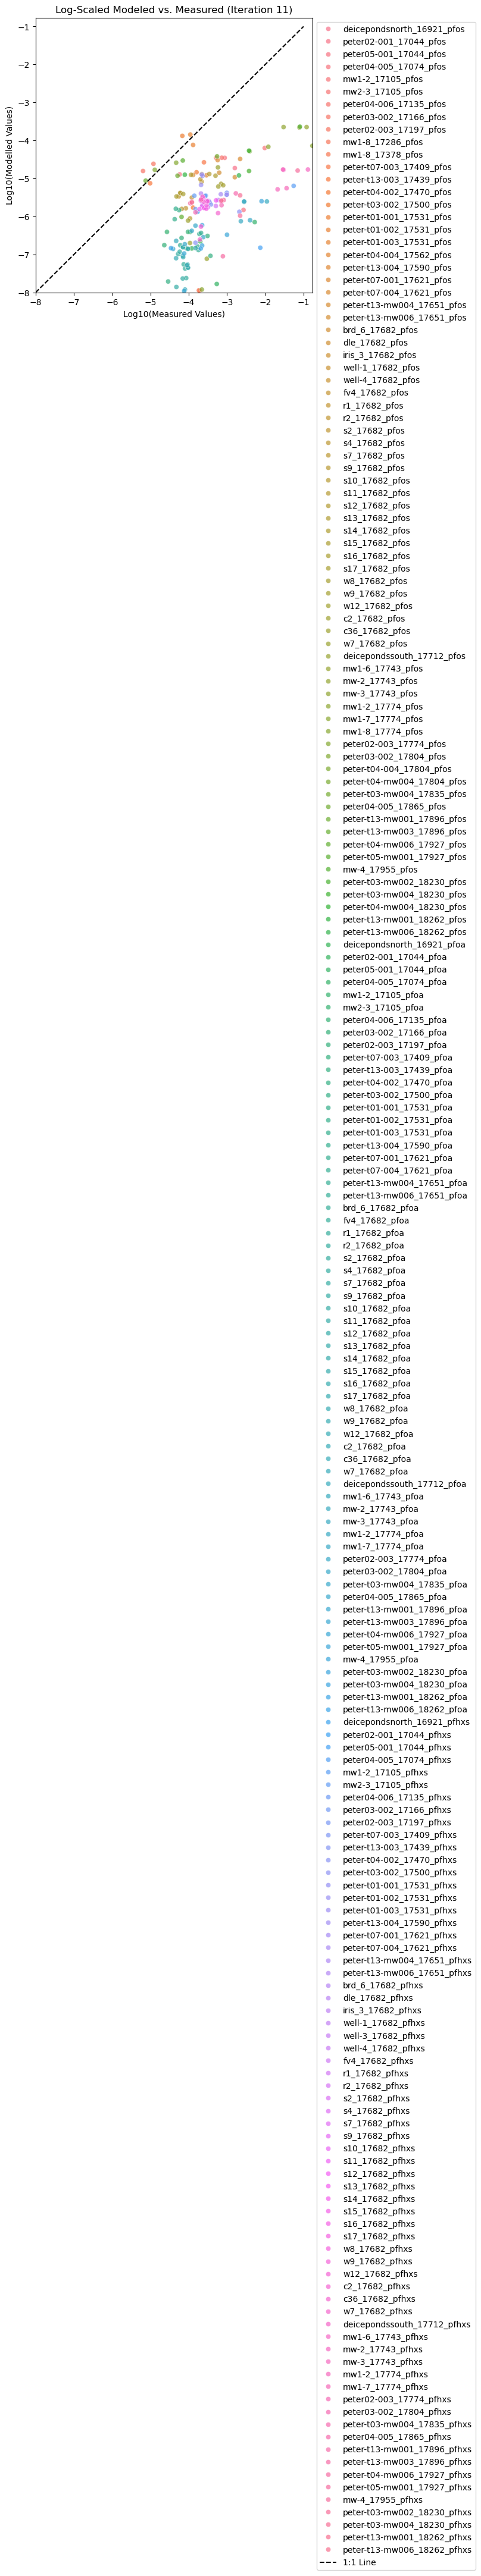

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter for the last iteration
last_iter = rei_df["iteration"].max()
rei_last = rei_df[rei_df["iteration"] == last_iter].copy()

# Add a small constant to avoid log(0) for both measured and modeled values
small_constant = 1e-10

# Apply log transformation (log10)
rei_last["log_measured"] = np.log10(rei_last["Measured"] + small_constant)
rei_last["log_modelled"] = np.log10(rei_last["Modelled"] + small_constant)

# Create the log-log plot
plt.figure(figsize=(6,6))
sns.scatterplot(data=rei_last, x="log_measured", y="log_modelled", hue="Name", alpha=0.7)

# Add a 1:1 line for reference
plt.plot([-8, -1],
         [-8, -1],
         color="black", linestyle="--", label="1:1 Line")


# Set equal axis limits (same limits for both axes)
min_val = min(rei_last["log_measured"].min(), rei_last["log_modelled"].min())
max_val = max(rei_last["log_measured"].max(), rei_last["log_modelled"].max())

plt.xlim(-8, max_val)
plt.ylim(-8, max_val)

# Labels and title
plt.xlabel("Log10(Measured Values)")
plt.ylabel("Log10(Modelled Values)")
plt.title(f"Log-Scaled Modeled vs. Measured (Iteration {last_iter})")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))  # Move legend outside
plt.show()

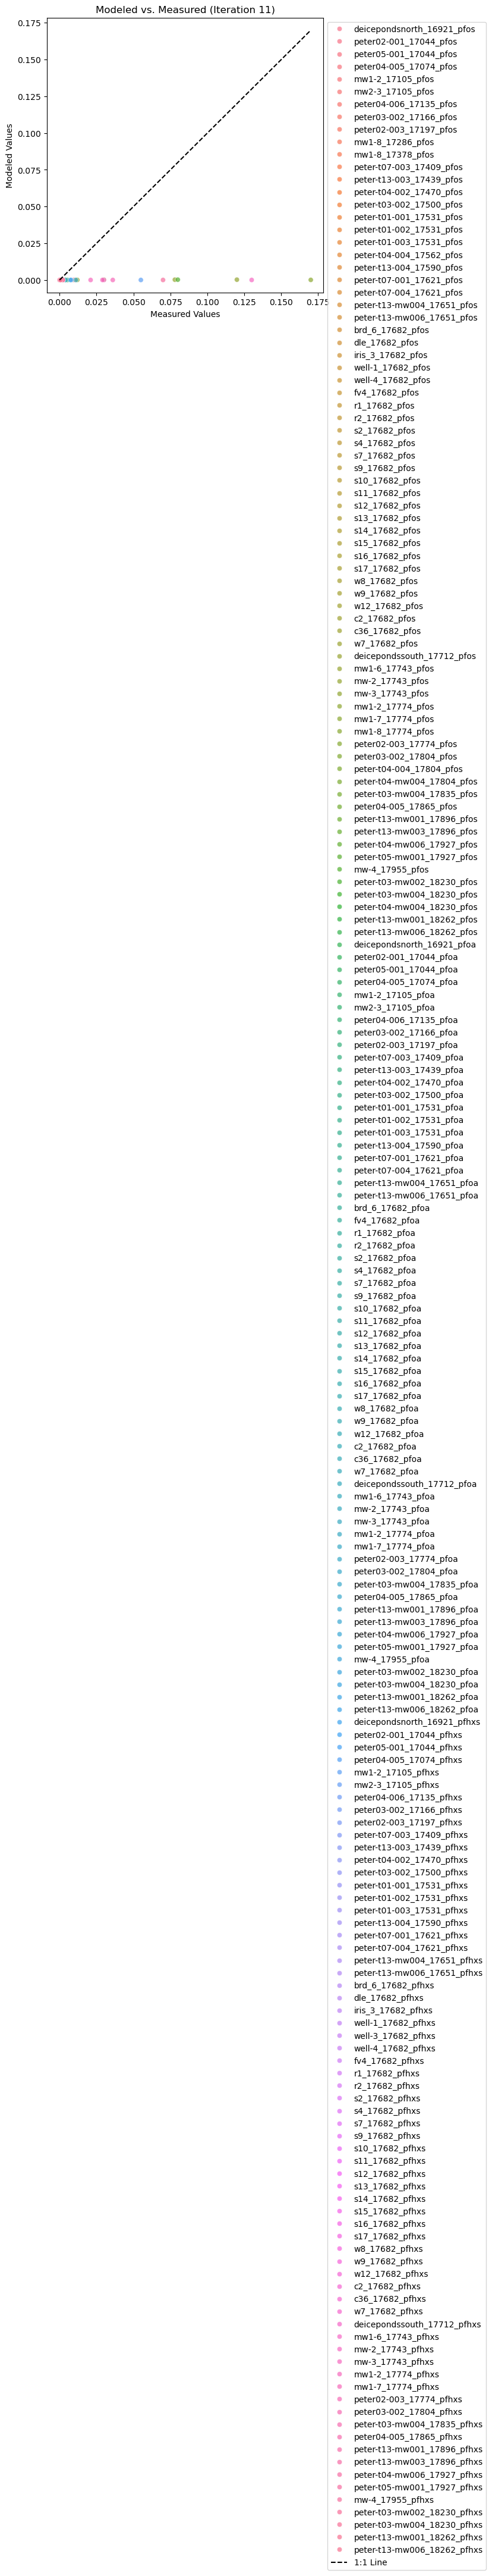

In [59]:
# Filter for the last iteration
last_iter = rei_df["iteration"].max()  # Get the max iteration number
rei_last = rei_df[rei_df["iteration"] == last_iter]  # Filter dataset

plt.figure(figsize=(6,6))

# Scatter plot
sns.scatterplot(data=rei_last, x="Measured", y="Modelled", hue="Name", alpha=0.7)

# 1:1 reference line
min_val = min(rei_last["Measured"].min(), rei_last["Modelled"].min())
max_val = max(rei_last["Measured"].max(), rei_last["Modelled"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", label="1:1 Line")

# Labels & title
plt.xlabel("Measured Values")
plt.ylabel("Modeled Values")
plt.title(f"Modeled vs. Measured (Iteration {last_iter})")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))  # Move legend outside

plt.show()

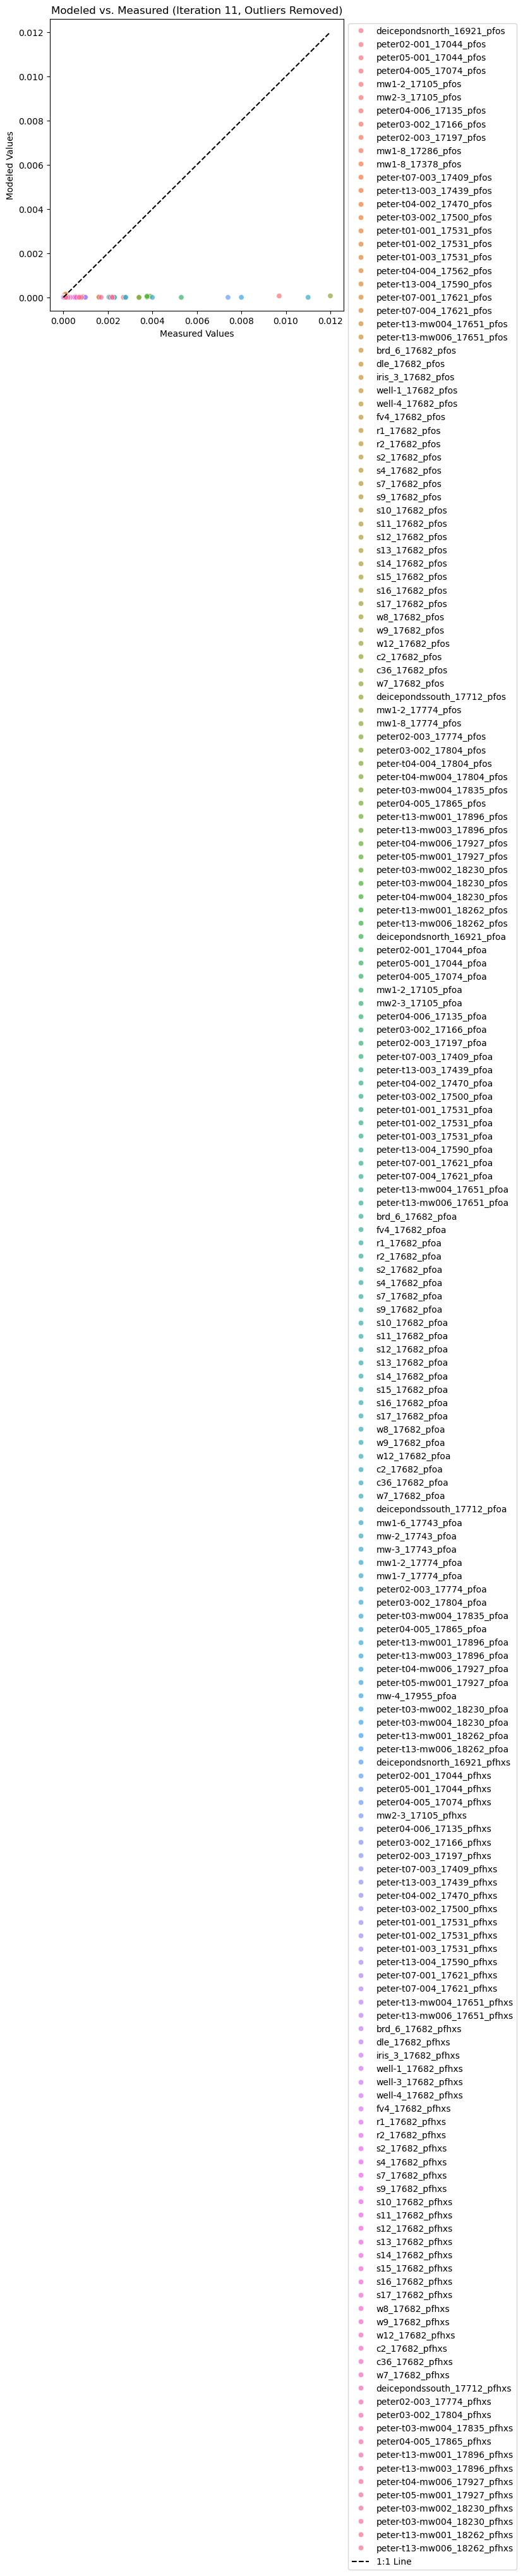

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter for the last iteration
last_iter = rei_df["iteration"].max()
rei_last = rei_df[rei_df["iteration"] == last_iter].copy()  # Work with a copy to avoid warnings

# Compute residuals
rei_last["residual"] = np.abs(rei_last["Modelled"] - rei_last["Measured"])

# Define threshold (e.g., 3x standard deviation)
residual_threshold = 1 * rei_last["residual"].std()

# Filter out high residuals
rei_filtered = rei_last[rei_last["residual"] <= residual_threshold]

plt.figure(figsize=(6,6))

# Scatter plot with filtered data
sns.scatterplot(data=rei_filtered, x="Measured", y="Modelled", hue="Name", alpha=0.7)

# 1:1 reference line
min_val = min(rei_filtered["Measured"].min(), rei_filtered["Modelled"].min())
max_val = max(rei_filtered["Measured"].max(), rei_filtered["Modelled"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", label="1:1 Line")

# Labels & title
plt.xlabel("Measured Values")
plt.ylabel("Modeled Values")
plt.title(f"Modeled vs. Measured (Iteration {last_iter}, Outliers Removed)")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))  # Move legend outside

plt.show()


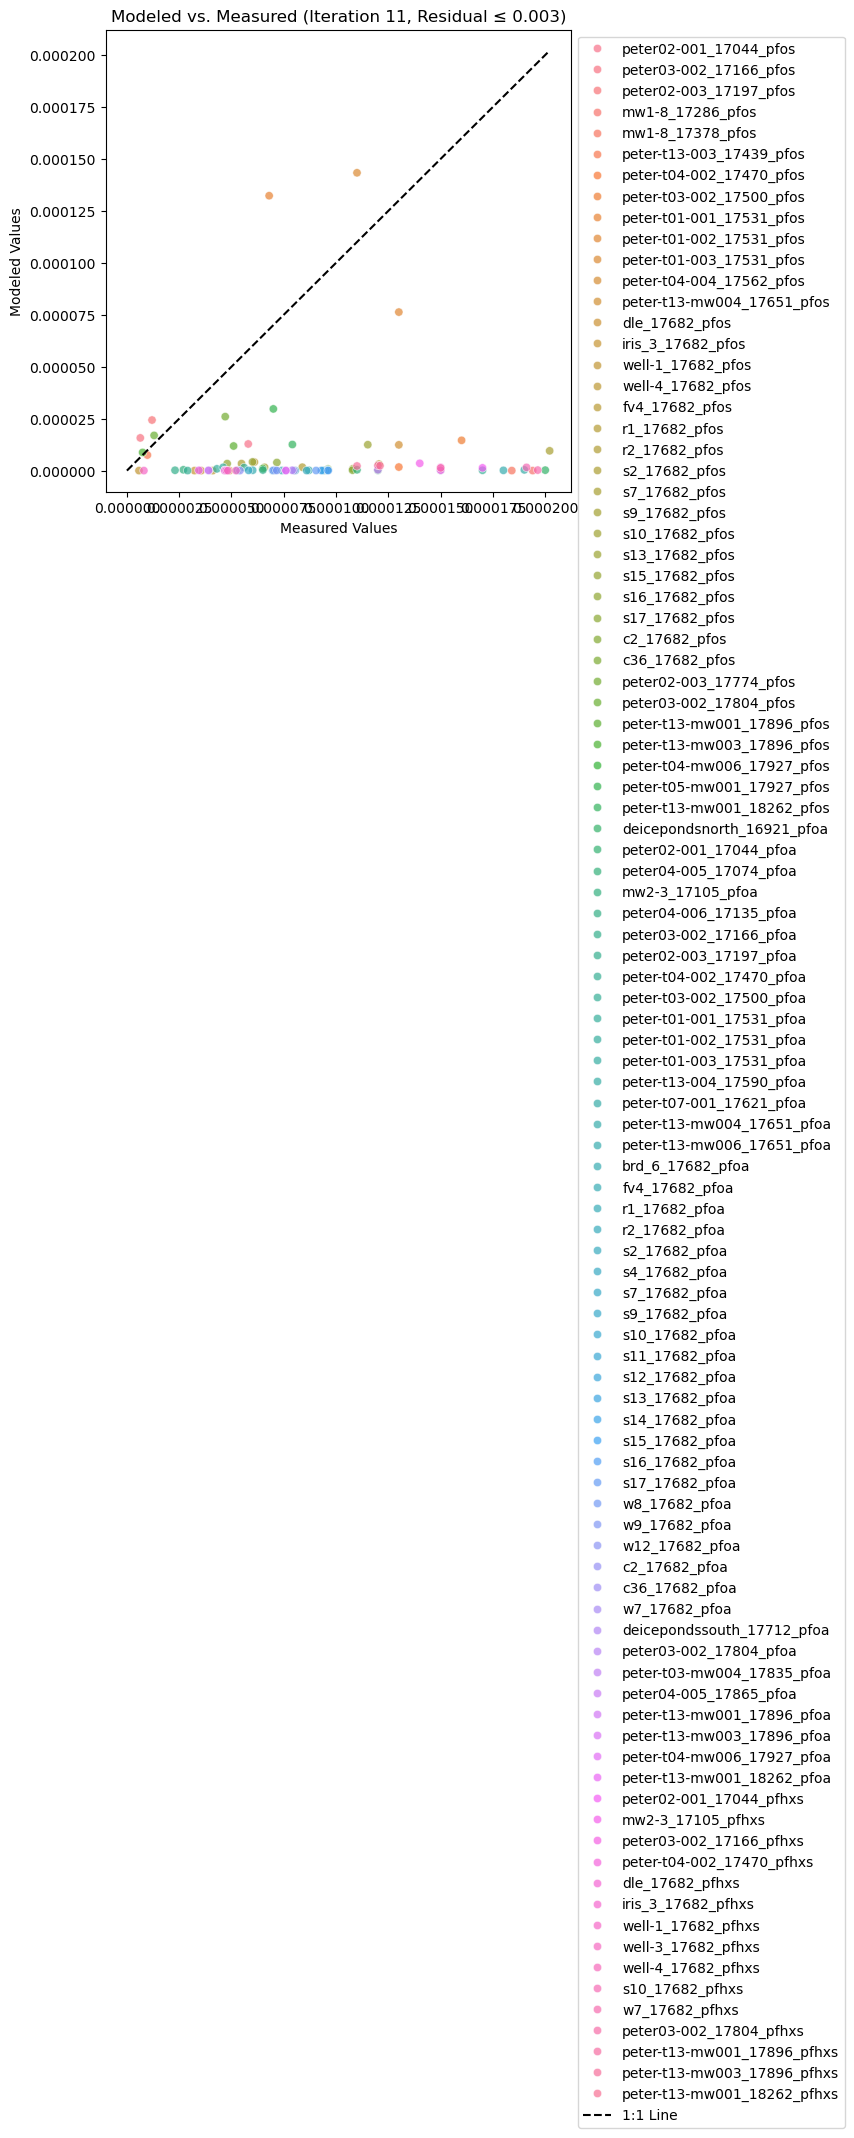

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter for the last iteration
last_iter = rei_df["iteration"].max()
rei_last = rei_df[rei_df["iteration"] == last_iter].copy()  # Work with a copy to avoid warnings

# Compute residuals
rei_last["residual"] = np.abs(rei_last["Modelled"] - rei_last["Measured"])

# Set residual threshold (0.003)
rei_filtered = rei_last[rei_last["residual"] <= 0.0002]

plt.figure(figsize=(6,6))

# Scatter plot with filtered data
sns.scatterplot(data=rei_filtered, x="Measured", y="Modelled", hue="Name", alpha=0.7)

# 1:1 reference line
min_val = min(rei_filtered["Measured"].min(), rei_filtered["Modelled"].min())
max_val = max(rei_filtered["Measured"].max(), rei_filtered["Modelled"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", label="1:1 Line")

# Labels & title
plt.xlabel("Measured Values")
plt.ylabel("Modeled Values")
plt.title(f"Modeled vs. Measured (Iteration {last_iter}, Residual ≤ 0.003)")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))  # Move legend outside

plt.show()


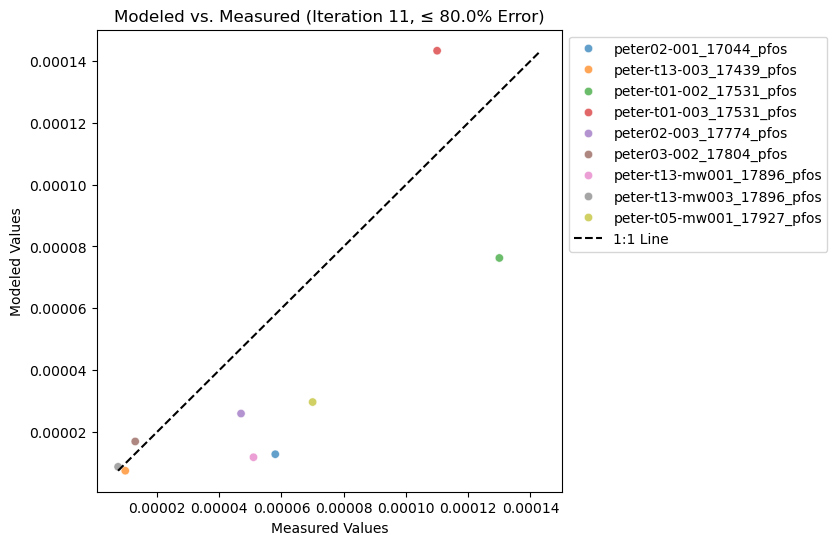

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter for the last iteration
last_iter = rei_df["iteration"].max()
rei_last = rei_df[rei_df["iteration"] == last_iter].copy()  # Work with a copy

# Compute relative residuals (avoid division by zero)
rei_last["rel_residual"] = np.abs(rei_last["Modelled"] - rei_last["Measured"]) / (rei_last["Measured"] + 1e-10)

# Set relative residual threshold (e.g., 5% error)
threshold = 0.8  # 5% cutoff
rei_filtered = rei_last[rei_last["rel_residual"] <= threshold]

plt.figure(figsize=(6,6))

# Scatter plot with filtered data
sns.scatterplot(data=rei_filtered, x="Measured", y="Modelled", hue="Name", alpha=0.7)

# 1:1 reference line
min_val = min(rei_filtered["Measured"].min(), rei_filtered["Modelled"].min())
max_val = max(rei_filtered["Measured"].max(), rei_filtered["Modelled"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", label="1:1 Line")

# Labels & title
plt.xlabel("Measured Values")
plt.ylabel("Modeled Values")
plt.title(f"Modeled vs. Measured (Iteration {last_iter}, ≤ {threshold*100}% Error)")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))  # Move legend outside

plt.show()

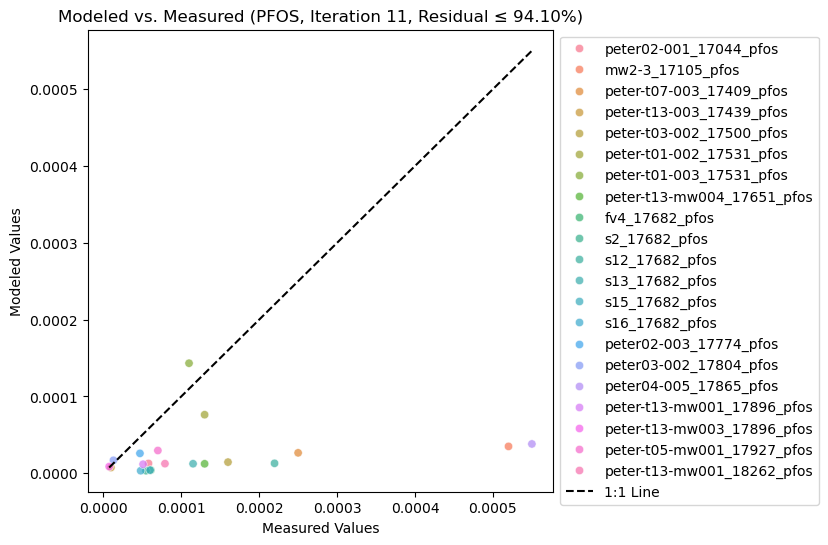

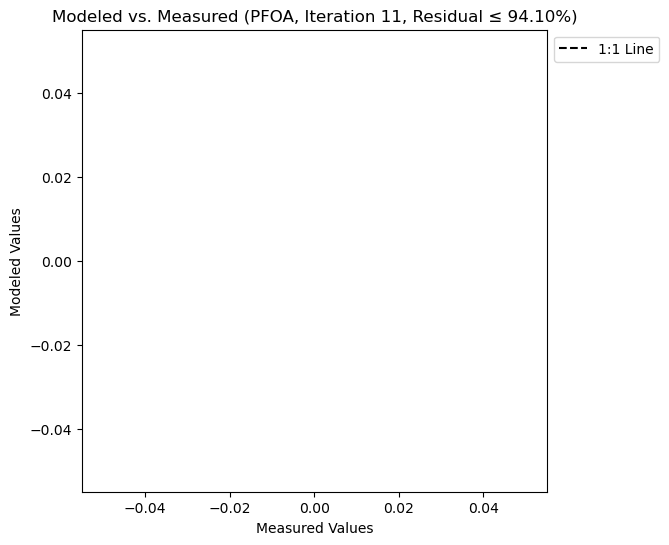

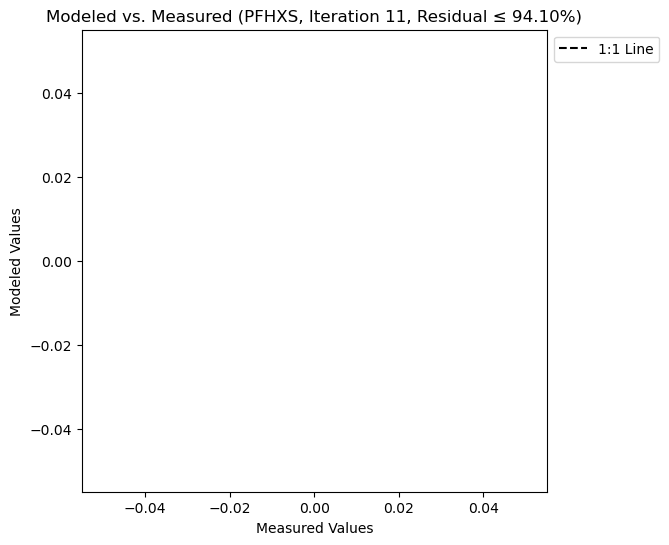

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter for the last iteration
last_iter = rei_df["iteration"].max()
rei_last = rei_df[rei_df["iteration"] == last_iter].copy()

# Compute relative residuals
rei_last["rel_residual"] = np.abs(rei_last["Modelled"] - rei_last["Measured"]) / (rei_last["Measured"].abs() + 1e-10)

# **Step 1: Adjust threshold dynamically (optional)**
threshold = np.percentile(rei_last["rel_residual"], 10)  # Keep 90% of the data
rei_filtered = rei_last[rei_last["rel_residual"] <= threshold]

# Separate data by observation name suffix
pfos_data = rei_filtered[rei_filtered["Name"].str.endswith("_pfos")]
pfoa_data = rei_filtered[rei_filtered["Name"].str.endswith("_pfoa")]
pfhxs_data = rei_filtered[rei_filtered["Name"].str.endswith("_pfhxs")]

# **Step 2: Create separate plots**
# Plot for PFOS
plt.figure(figsize=(6,6))
sns.scatterplot(data=pfos_data, x="Measured", y="Modelled", hue="Name", alpha=0.7)
plt.plot([pfos_data["Measured"].min(), pfos_data["Measured"].max()], 
         [pfos_data["Measured"].min(), pfos_data["Measured"].max()], 
         color="black", linestyle="--", label="1:1 Line")
plt.xlabel("Measured Values")
plt.ylabel("Modeled Values")
plt.title(f"Modeled vs. Measured (PFOS, Iteration {last_iter}, Residual ≤ {threshold:.2%})")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.show()

# Plot for PFOA
plt.figure(figsize=(6,6))
sns.scatterplot(data=pfoa_data, x="Measured", y="Modelled", hue="Name", alpha=0.7)
plt.plot([pfoa_data["Measured"].min(), pfoa_data["Measured"].max()], 
         [pfoa_data["Measured"].min(), pfoa_data["Measured"].max()], 
         color="black", linestyle="--", label="1:1 Line")
plt.xlabel("Measured Values")
plt.ylabel("Modeled Values")
plt.title(f"Modeled vs. Measured (PFOA, Iteration {last_iter}, Residual ≤ {threshold:.2%})")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.show()

# Plot for PFHXS
plt.figure(figsize=(6,6))
sns.scatterplot(data=pfhxs_data, x="Measured", y="Modelled", hue="Name", alpha=0.7)
plt.plot([pfhxs_data["Measured"].min(), pfhxs_data["Measured"].max()], 
         [pfhxs_data["Measured"].min(), pfhxs_data["Measured"].max()], 
         color="black", linestyle="--", label="1:1 Line")
plt.xlabel("Measured Values")
plt.ylabel("Modeled Values")
plt.title(f"Modeled vs. Measured (PFHXS, Iteration {last_iter}, Residual ≤ {threshold:.2%})")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.show()


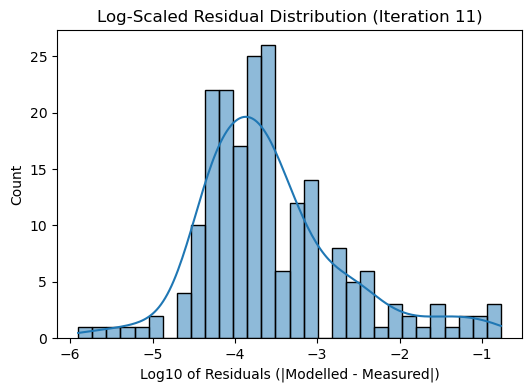

Threshold used: -2.43
Remaining points after filtering: 181


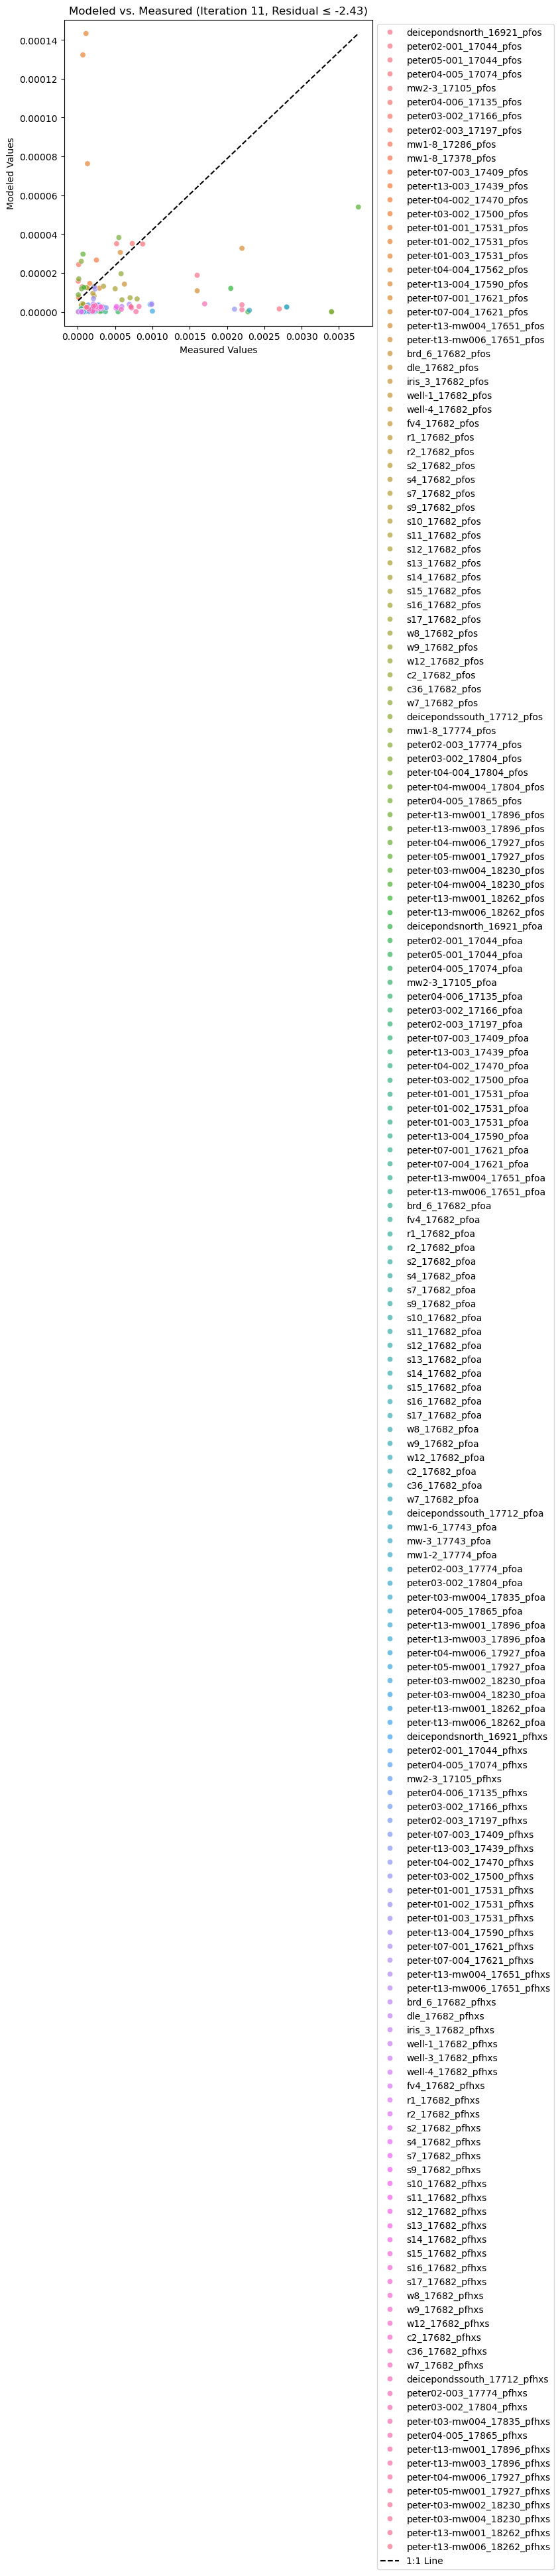

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter for the last iteration
last_iter = rei_df["iteration"].max()
rei_last = rei_df[rei_df["iteration"] == last_iter].copy()

# Compute residuals and apply log scale (avoid log(0) by adding a small constant)
rei_last["residual"] = np.abs(rei_last["Modelled"] - rei_last["Measured"])
rei_last["log_residual"] = np.log10(rei_last["residual"] + 1e-10)  # Log scale with small constant

# Compute relative residual
rei_last["rel_residual"] = np.abs(rei_last["Modelled"] - rei_last["Measured"]) / (rei_last["Measured"].abs() + 1e-10)

# **Step 1: Plot histogram of log-scaled residuals**
plt.figure(figsize=(6,4))
sns.histplot(rei_last["log_residual"], bins=30, kde=True)
plt.xlabel("Log10 of Residuals (|Modelled - Measured|)")
plt.title(f"Log-Scaled Residual Distribution (Iteration {last_iter})")
plt.show()

# **Step 2: Use dynamic threshold (based on log residuals)**
threshold = np.percentile(rei_last["log_residual"], 90)  # Keep 90% of the data
rei_filtered = rei_last[rei_last["log_residual"] <= threshold]

print(f"Threshold used: {threshold:.2f}")
print(f"Remaining points after filtering: {len(rei_filtered)}")

# **Step 3: Plot Modeled vs Measured with filtered data**
plt.figure(figsize=(6,6))
sns.scatterplot(data=rei_filtered, x="Measured", y="Modelled", hue="Name", alpha=0.7)
plt.plot([rei_filtered["Measured"].min(), rei_filtered["Measured"].max()], 
         [rei_filtered["Measured"].min(), rei_filtered["Modelled"].max()], 
         color="black", linestyle="--", label="1:1 Line")

# Labels & title
plt.xlabel("Measured Values")
plt.ylabel("Modeled Values")
plt.title(f"Modeled vs. Measured (Iteration {last_iter}, Residual ≤ {threshold:.2f})")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))  # Move legend outside
plt.show()
